# Employee Attrition — Machine Learning

In this section, we will build and evaluate machine learning models to predict employee attrition.

The workflow will include:

- Loading the cleaned dataset
- Defining the target variable and features
- Splitting the data into training and testing sets
- Preprocessing numerical and categorical features
- Handling class imbalance using SMOTE on the training data only
- Training and comparing multiple classification models
- Evaluating model performance using appropriate metrics
- Hyperparameter tuning for the best-performing models
- Analyzing feature importance
- Selecting the final model

In [3]:
# Step 1 — Load the Cleaned Dataset

import pandas as pd

df = pd.read_csv('cleaned_data.csv')

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (1470, 39)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,TenureFraction,LogMonthlyIncome,OvertimeFlag,JobLevelInvolvement
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,0,1,6,4,0,5,0.146341,8.698514,1,6
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,3,3,10,7,1,7,0.204082,8.543056,0,4
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,3,3,0,0,0,0,0.000000,7.645398,1,2
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,3,8,7,3,0,0.242424,7.975908,1,3
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,3,3,2,2,2,2,0.074074,8.151622,0,3


## Step 2 — Define Target and Features

The target variable is `Attrition`, which indicates whether an employee left the company.

We will separate the target from the input features before splitting the data into training and testing sets.

In [4]:
# Separate features and target

X = df.drop(columns='Attrition')
y = df['Attrition']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())

Features shape: (1470, 38)
Target shape: (1470,)

Target distribution:
Attrition
No     1233
Yes     237
Name: count, dtype: int64


## Step 3 — Train/Test Split

We will split the dataset into training and testing sets before applying any preprocessing or resampling techniques.

A stratified split will be used to preserve the original class distribution of the `Attrition` target in both sets.

In [5]:
# Split the data into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training set: (1176, 38)
Testing set: (294, 38)

Training target distribution:
Attrition
No     0.838435
Yes    0.161565
Name: proportion, dtype: float64

Testing target distribution:
Attrition
No     0.840136
Yes    0.159864
Name: proportion, dtype: float64


## Step 4 — Preprocessing

Before training the models, we need to convert categorical features into numerical representations and scale numerical features when required.

We will use a `ColumnTransformer` to apply the appropriate preprocessing to each feature type.

- Numerical features will be standardized using `StandardScaler`.
- Categorical features will be converted using `OneHotEncoder`.
- The preprocessing will be fitted on the training data only to prevent data leakage.

In [6]:
# Identify numerical and categorical features

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numerical_cols = X_train.select_dtypes(include='number').columns
categorical_cols = X_train.select_dtypes(include='object').columns

print("Numerical features:", len(numerical_cols))
print("Categorical features:", len(categorical_cols))

# Build preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ]
)

# Fit on training data and transform both sets
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("\nProcessed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Numerical features: 30
Categorical features: 8

Processed training shape: (1176, 59)
Processed testing shape: (294, 59)


## Step 5 — Handle Class Imbalance with SMOTE

The target variable is imbalanced, with the minority class (`Yes`) representing approximately 16% of the dataset.

We will apply SMOTE to the training data only to generate synthetic samples for the minority class.

The test set will remain unchanged so that model evaluation reflects the original class distribution.

In [7]:
# Apply SMOTE to the training data only

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_processed,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_resampled.value_counts())

print("\nTraining shape after SMOTE:", X_train_resampled.shape)

Before SMOTE:
Attrition
No     986
Yes    190
Name: count, dtype: int64

After SMOTE:
Attrition
No     986
Yes    986
Name: count, dtype: int64

Training shape after SMOTE: (1972, 59)


## Step 6 — Train Baseline Classification Models

We will train several baseline classification models to establish a performance benchmark.

The models selected represent different learning approaches:

- Logistic Regression — linear baseline and highly interpretable.
- Decision Tree — captures nonlinear relationships.
- Random Forest — ensemble of decision trees with strong general performance.
- Support Vector Machine (SVM) — effective for high-dimensional feature spaces.

The models will be evaluated on the original, imbalanced test set using metrics suitable for imbalanced classification.

In [8]:
# Train baseline classification models

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    'Decision Tree': DecisionTreeClassifier(
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    'SVM': SVC(
        probability=True,
        random_state=42
    )
}

for name, model in models.items():
    model.fit(X_train_resampled, y_train_resampled)
    print(f"{name} trained successfully.")

Logistic Regression trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.
SVM trained successfully.


## Step 7 — Evaluate Baseline Models

We will evaluate the baseline models on the untouched test set.

Because the target variable is imbalanced, accuracy alone is not sufficient. We will focus on:

- Precision
- Recall
- F1-score
- ROC-AUC
- Confusion Matrix

These metrics provide a more reliable assessment of how well each model identifies employees at risk of attrition.

In [9]:
# Evaluate baseline models

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

results = []

for name, model in models.items():
    y_pred = model.predict(X_test_processed)
    y_prob = model.predict_proba(X_test_processed)[:, 1]

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, pos_label='Yes'),
        'Recall': recall_score(y_test, y_pred, pos_label='Yes'),
        'F1-Score': f1_score(y_test, y_pred, pos_label='Yes'),
        'ROC-AUC': roc_auc_score(
            (y_test == 'Yes').astype(int),
            y_prob
        )
    })

results_df = pd.DataFrame(results).sort_values(
    by='F1-Score',
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
3,SVM,0.853741,0.547619,0.489362,0.516854,0.751486
0,Logistic Regression,0.785714,0.394737,0.638298,0.487805,0.797312
2,Random Forest,0.850340,0.571429,0.255319,0.352941,0.794814
1,Decision Tree,0.792517,0.347826,0.340426,0.344086,0.609484


## Step 8 — Detailed Model Evaluation

The baseline results show different trade-offs between precision and recall.

Since identifying employees who are likely to leave is an important objective, we will examine the confusion matrix and classification report for each model.

This will help us understand the types of errors each model makes, particularly false negatives where an employee who actually left is predicted as staying.

Logistic Regression
              precision    recall  f1-score   support

          No       0.92      0.81      0.86       247
         Yes       0.39      0.64      0.49        47

    accuracy                           0.79       294
   macro avg       0.66      0.73      0.68       294
weighted avg       0.84      0.79      0.80       294



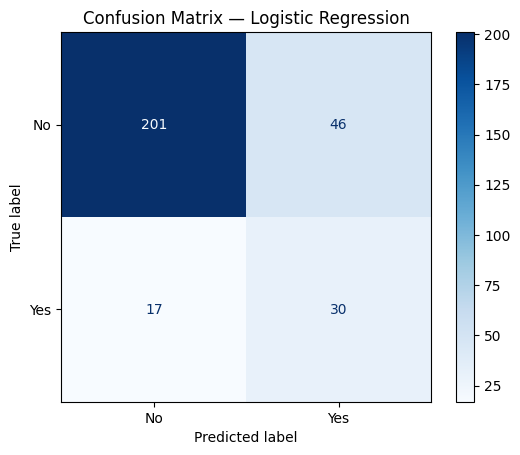

Decision Tree
              precision    recall  f1-score   support

          No       0.88      0.88      0.88       247
         Yes       0.35      0.34      0.34        47

    accuracy                           0.79       294
   macro avg       0.61      0.61      0.61       294
weighted avg       0.79      0.79      0.79       294



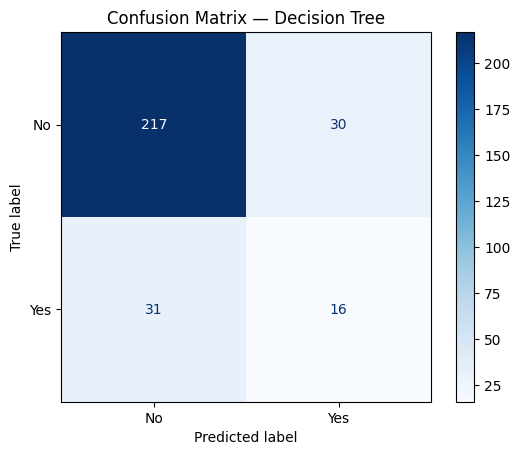

Random Forest
              precision    recall  f1-score   support

          No       0.87      0.96      0.92       247
         Yes       0.57      0.26      0.35        47

    accuracy                           0.85       294
   macro avg       0.72      0.61      0.63       294
weighted avg       0.82      0.85      0.83       294



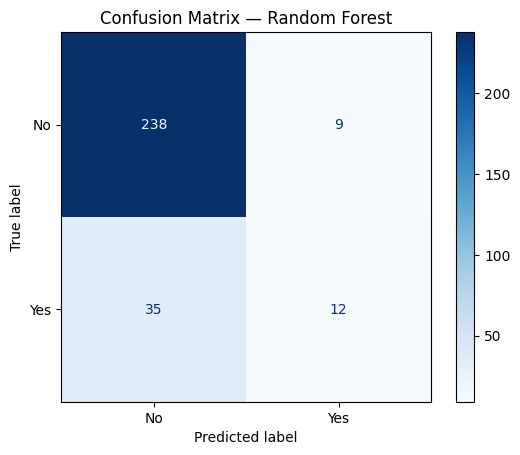

SVM
              precision    recall  f1-score   support

          No       0.90      0.92      0.91       247
         Yes       0.55      0.49      0.52        47

    accuracy                           0.85       294
   macro avg       0.73      0.71      0.72       294
weighted avg       0.85      0.85      0.85       294



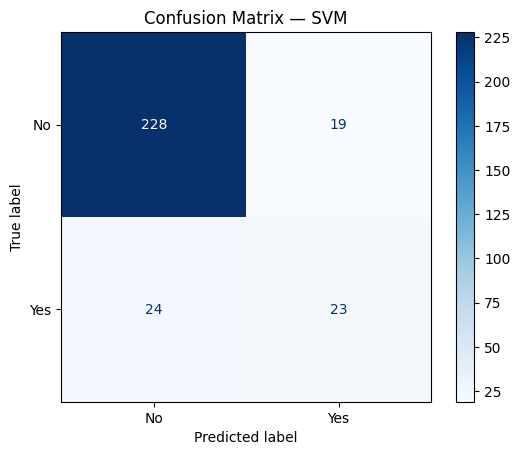

In [11]:
# Detailed evaluation of baseline models

import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, ConfusionMatrixDisplay

for name, model in models.items():
    y_pred = model.predict(X_test_processed)

    print("=" * 60)
    print(name)
    print("=" * 60)

    print(classification_report(
        y_test,
        y_pred,
        target_names=['No', 'Yes']
    ))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        display_labels=['No', 'Yes'],
        cmap='Blues'
    )

    plt.title(f'Confusion Matrix — {name}')
    plt.show()

## Step 9 — Hyperparameter Tuning

The baseline evaluation shows that Logistic Regression, SVM, and Random Forest are the strongest candidates, but they have different strengths.

We will tune these models using cross-validation on the training data only.

Because detecting employees who may leave is important, we will optimize for **F1-score** for the `Yes` class, which balances precision and recall.

The test set will remain untouched until the final evaluation.

In [14]:
# Step 9 — Lightweight Hyperparameter Tuning

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, f1_score

# Define F1-score for the Attrition = Yes class
f1_yes = make_scorer(
    f1_score,
    pos_label='Yes'
)

param_grids = {
    'Logistic Regression': {
        'C': [0.1, 1, 10],
        'solver': ['liblinear']
    },

    'SVM': {
        'C': [0.1, 1, 10],
        'kernel': ['rbf'],
        'gamma': ['scale']
    },

    'Random Forest': {
        'n_estimators': [100, 200],
        'max_depth': [None, 10],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    }
}

tuned_models = {}
tuning_results = {}

for name, param_grid in param_grids.items():

    grid_search = GridSearchCV(
        estimator=models[name],
        param_grid=param_grid,
        scoring=f1_yes,
        cv=5,
        n_jobs=2,
        verbose=1
    )

    grid_search.fit(
        X_train_resampled,
        y_train_resampled
    )

    tuned_models[name] = grid_search.best_estimator_

    tuning_results[name] = {
        'Best Parameters': grid_search.best_params_,
        'Best CV F1': grid_search.best_score_
    }

    print(f"\n{name}")
    print(f"Best Parameters: {grid_search.best_params_}")
    print(f"Best CV F1: {grid_search.best_score_:.4f}")
    print("-" * 60)

Fitting 5 folds for each of 3 candidates, totalling 15 fits

Logistic Regression
Best Parameters: {'C': 10, 'solver': 'liblinear'}
Best CV F1: 0.8055
------------------------------------------------------------
Fitting 5 folds for each of 3 candidates, totalling 15 fits

SVM
Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV F1: 0.9654
------------------------------------------------------------
Fitting 5 folds for each of 16 candidates, totalling 80 fits

Random Forest
Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV F1: 0.9289
------------------------------------------------------------


## Step 10 — Evaluate Tuned Models

The hyperparameter tuning process identified the best configuration for each candidate model.

We will now evaluate the tuned models on the untouched test set and compare their performance using the same classification metrics used for the baseline models.

The test set has not been resampled and will be used only for final model evaluation.

In [15]:
# Evaluate tuned models on the untouched test set

tuned_results = []

for name, model in tuned_models.items():
    y_pred = model.predict(X_test_processed)
    y_prob = model.predict_proba(X_test_processed)[:, 1]

    tuned_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, pos_label='Yes'),
        'Recall': recall_score(y_test, y_pred, pos_label='Yes'),
        'F1-Score': f1_score(y_test, y_pred, pos_label='Yes'),
        'ROC-AUC': roc_auc_score(
            (y_test == 'Yes').astype(int),
            y_prob
        )
    })

tuned_results_df = (
    pd.DataFrame(tuned_results)
    .sort_values(by='F1-Score', ascending=False)
    .reset_index(drop=True)
)

tuned_results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,SVM,0.863946,0.620690,0.382979,0.473684,0.737790
1,Logistic Regression,0.772109,0.375000,0.638298,0.472441,0.796451
2,Random Forest,0.846939,0.545455,0.255319,0.347826,0.787019


## Step 11 — XGBoost Baseline

XGBoost is a powerful gradient boosting algorithm that can capture nonlinear relationships and feature interactions.

We will train an XGBoost classifier on the SMOTE-balanced training data and evaluate it on the untouched test set.

This model will be compared with the previously trained Logistic Regression, SVM, and Random Forest models.

In [17]:
# Step 11 — XGBoost Baseline

from xgboost import XGBClassifier

# Encode target: No = 0, Yes = 1
y_train_xgb = y_train_resampled.map({'No': 0, 'Yes': 1})
y_test_xgb = y_test.map({'No': 0, 'Yes': 1})

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    n_jobs=2
)

xgb_model.fit(
    X_train_resampled,
    y_train_xgb
)

print("XGBoost trained successfully.")

XGBoost trained successfully.


## Step 12 — Evaluate XGBoost

We will evaluate the XGBoost baseline on the untouched test set using the same metrics used for the other models.

The positive class is `Yes`, representing employees who left the company.

In [19]:
# Evaluate XGBoost baseline

y_pred_xgb = xgb_model.predict(X_test_processed)
y_prob_xgb = xgb_model.predict_proba(X_test_processed)[:, 1]

xgb_results = {
    'Model': 'XGBoost',
    'Accuracy': accuracy_score(y_test_xgb, y_pred_xgb),
    'Precision': precision_score(y_test_xgb, y_pred_xgb),
    'Recall': recall_score(y_test_xgb, y_pred_xgb),
    'F1-Score': f1_score(y_test_xgb, y_pred_xgb),
    'ROC-AUC': roc_auc_score(y_test_xgb, y_prob_xgb)
}

print("XGBoost Performance:")
print(f"Model: {xgb_results['Model']}")

for metric in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']:
    print(f"{metric}: {xgb_results[metric]:.4f}")

XGBoost Performance:
Model: XGBoost
Accuracy: 0.8673
Precision: 0.6667
Recall: 0.3404
F1-Score: 0.4507
ROC-AUC: 0.7909


## Step 13 — Optimize Classification Threshold

Most classification models use a default probability threshold of 0.5 to classify observations.

For employee attrition, this threshold may not provide the best balance between precision and recall.

We will evaluate different probability thresholds and identify a threshold that provides a better F1-score for the `Yes` class.

In [20]:
# Compare different classification thresholds

import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

# Use the best current candidate: Logistic Regression
best_model = tuned_models['Logistic Regression']

y_prob = best_model.predict_proba(X_test_processed)[:, 1]

threshold_results = []

for threshold in np.arange(0.20, 0.71, 0.05):
    y_pred_threshold = np.where(
        y_prob >= threshold,
        'Yes',
        'No'
    )

    threshold_results.append({
        'Threshold': round(threshold, 2),
        'Precision': precision_score(
            y_test,
            y_pred_threshold,
            pos_label='Yes'
        ),
        'Recall': recall_score(
            y_test,
            y_pred_threshold,
            pos_label='Yes'
        ),
        'F1-Score': f1_score(
            y_test,
            y_pred_threshold,
            pos_label='Yes'
        )
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df.sort_values(
    by='F1-Score',
    ascending=False
).reset_index(drop=True)

,Threshold,Precision,Recall,F1-Score
0,0.55,0.405797,0.595745,0.482759
1,0.65,0.469388,0.489362,0.479167
2,0.60,0.412698,0.553191,0.472727
3,0.50,0.375000,0.638298,0.472441
4,0.40,0.350515,0.723404,0.472222
5,0.45,0.352273,0.659574,0.459259
6,0.70,0.456522,0.446809,0.451613
7,0.35,0.323810,0.723404,0.447368
8,0.30,0.300000,0.765957,0.431138
9,0.25,0.276119,0.787234,0.408840


## Step 14 — Compare Classification Thresholds Across Models

Different models may achieve better precision-recall trade-offs at different probability thresholds.

We will compare threshold performance for Logistic Regression, SVM, and XGBoost using the untouched test set.

The goal is to identify the model and threshold that provide the best balance between precision and recall for the `Yes` class.

In [21]:
# Compare thresholds across the strongest models

threshold_models = {
    'Logistic Regression': tuned_models['Logistic Regression'],
    'SVM': tuned_models['SVM'],
    'XGBoost': xgb_model
}

threshold_results = []

for name, model in threshold_models.items():

    y_prob = model.predict_proba(X_test_processed)[:, 1]

    for threshold in np.arange(0.20, 0.71, 0.05):

        y_pred = np.where(
            y_prob >= threshold,
            'Yes',
            'No'
        )

        threshold_results.append({
            'Model': name,
            'Threshold': round(threshold, 2),
            'Precision': precision_score(
                y_test,
                y_pred,
                pos_label='Yes'
            ),
            'Recall': recall_score(
                y_test,
                y_pred,
                pos_label='Yes'
            ),
            'F1-Score': f1_score(
                y_test,
                y_pred,
                pos_label='Yes'
            )
        })

threshold_comparison = pd.DataFrame(threshold_results)

threshold_comparison.sort_values(
    by='F1-Score',
    ascending=False
).reset_index(drop=True)

,Model,Threshold,Precision,Recall,F1-Score
0,XGBoost,0.20,0.390805,0.723404,0.507463
1,Logistic Regression,0.55,0.405797,0.595745,0.482759
2,Logistic Regression,0.65,0.469388,0.489362,0.479167
3,SVM,0.30,0.708333,0.361702,0.478873
4,SVM,0.20,0.620690,0.382979,0.473684
5,Logistic Regression,0.60,0.412698,0.553191,0.472727
6,Logistic Regression,0.50,0.375000,0.638298,0.472441
7,Logistic Regression,0.40,0.350515,0.723404,0.472222
8,SVM,0.25,0.680000,0.361702,0.472222
9,XGBoost,0.35,0.488372,0.446809,0.466667


## Step 15 — Select the Optimal Threshold Using Validation Data

To avoid test-set leakage, the classification threshold should not be selected using the final test set.

We will split the resampled training data into a training subset and a validation subset. The model will be trained on the training subset, while the validation subset will be used to select the probability threshold that maximizes F1-score for the `Yes` class.

The final test set will remain untouched until the final evaluation.

In [22]:
# Step 15 — Validation-based Threshold Selection

from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

# Split the SMOTE-balanced training data
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train_resampled,
    y_train_resampled,
    test_size=0.20,
    random_state=42,
    stratify=y_train_resampled
)

# Train the XGBoost model on the training subset
xgb_validation = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    n_jobs=2
)

xgb_validation.fit(
    X_train_sub,
    y_train_sub.map({'No': 0, 'Yes': 1})
)

# Validation probabilities
y_val_prob = xgb_validation.predict_proba(X_val)[:, 1]

threshold_results = []

for threshold in np.arange(0.20, 0.71, 0.05):

    y_val_pred = np.where(
        y_val_prob >= threshold,
        'Yes',
        'No'
    )

    threshold_results.append({
        'Threshold': round(threshold, 2),
        'Precision': precision_score(
            y_val,
            y_val_pred,
            pos_label='Yes'
        ),
        'Recall': recall_score(
            y_val,
            y_val_pred,
            pos_label='Yes'
        ),
        'F1-Score': f1_score(
            y_val,
            y_val_pred,
            pos_label='Yes'
        )
    })

validation_thresholds = (
    pd.DataFrame(threshold_results)
    .sort_values('F1-Score', ascending=False)
    .reset_index(drop=True)
)

validation_thresholds

,Threshold,Precision,Recall,F1-Score
0,0.55,0.972067,0.883249,0.925532
1,0.60,0.988439,0.868020,0.924324
2,0.50,0.951087,0.888325,0.918635
3,0.65,0.988304,0.857868,0.918478
4,0.70,0.994083,0.852792,0.918033
5,0.45,0.936508,0.898477,0.917098
6,0.35,0.914141,0.918782,0.916456
7,0.40,0.927083,0.903553,0.915167
8,0.30,0.892157,0.923858,0.907731
9,0.25,0.847926,0.934010,0.888889


## Step 16 — Final XGBoost Evaluation

The optimal classification threshold was selected using the validation set, with a threshold of 0.45 providing the best F1-score.

We will now retrain XGBoost on the complete SMOTE-balanced training data and evaluate it once on the untouched test set using the selected threshold.

This provides the final unbiased performance estimate of the model.

In [23]:
# Step 16 — Final XGBoost Model

final_threshold = 0.45

# Train XGBoost on the complete SMOTE-balanced training data
final_xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    n_jobs=2
)

final_xgb.fit(
    X_train_resampled,
    y_train_resampled.map({'No': 0, 'Yes': 1})
)

# Predict probabilities on untouched test set
y_test_prob = final_xgb.predict_proba(X_test_processed)[:, 1]

# Apply selected threshold
y_test_pred = np.where(
    y_test_prob >= final_threshold,
    1,
    0
)

# Final evaluation
final_accuracy = accuracy_score(y_test_xgb, y_test_pred)
final_precision = precision_score(y_test_xgb, y_test_pred)
final_recall = recall_score(y_test_xgb, y_test_pred)
final_f1 = f1_score(y_test_xgb, y_test_pred)
final_roc_auc = roc_auc_score(y_test_xgb, y_test_prob)

print("=" * 60)
print("FINAL XGBOOST PERFORMANCE")
print("=" * 60)
print(f"Threshold: {final_threshold}")
print(f"Accuracy:  {final_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall:    {final_recall:.4f}")
print(f"F1-Score:  {final_f1:.4f}")
print(f"ROC-AUC:   {final_roc_auc:.4f}")
print("=" * 60)

FINAL XGBOOST PERFORMANCE
Threshold: 0.45
Accuracy:  0.8537
Precision: 0.5667
Recall:    0.3617
F1-Score:  0.4416
ROC-AUC:   0.7909


## Step 17 — Leakage-Free Cross-Validation with SMOTE

SMOTE should be applied only to the training portion of each cross-validation fold.

Applying SMOTE before cross-validation can cause synthetic samples derived from observations in the validation fold to influence the training folds, leading to overly optimistic validation results.

We will use an imbalanced-learn Pipeline so that SMOTE is applied independently inside each training fold.

In [25]:
# Step 17 — Leakage-Free Hyperparameter Tuning with SMOTE

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Encode target for XGBoost compatibility
y_train_encoded = y_train.map({
    'No': 0,
    'Yes': 1
})

# F1-score for the positive class (Yes = 1)
f1_yes = make_scorer(
    f1_score,
    pos_label=1
)

models_pipeline = {

    'Logistic Regression': Pipeline([
        ('smote', SMOTE(random_state=42)),
        ('model', LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]),

    'SVM': Pipeline([
        ('smote', SMOTE(random_state=42)),
        ('model', SVC(
            probability=True,
            random_state=42
        ))
    ]),

    'Random Forest': Pipeline([
        ('smote', SMOTE(random_state=42)),
        ('model', RandomForestClassifier(
            random_state=42,
            n_jobs=2
        ))
    ]),

    'XGBoost': Pipeline([
        ('smote', SMOTE(random_state=42)),
        ('model', XGBClassifier(
            random_state=42,
            eval_metric='logloss',
            n_jobs=2
        ))
    ])
}

# Lightweight parameter grids
param_grids_pipeline = {

    'Logistic Regression': {
        'model__C': [0.1, 1, 10]
    },

    'SVM': {
        'model__C': [0.1, 1, 10],
        'model__kernel': ['rbf']
    },

    'Random Forest': {
        'model__n_estimators': [100, 200],
        'model__max_depth': [None, 10],
        'model__min_samples_split': [2, 5]
    },

    'XGBoost': {
        'model__n_estimators': [100, 200],
        'model__learning_rate': [0.05, 0.1],
        'model__max_depth': [3, 4]
    }
}

leakage_free_models = {}
leakage_free_results = {}

for name in models_pipeline:

    print(f"\n{'=' * 60}")
    print(f"Tuning {name}")
    print(f"{'=' * 60}")

    grid_search = GridSearchCV(
        estimator=models_pipeline[name],
        param_grid=param_grids_pipeline[name],
        scoring=f1_yes,
        cv=5,
        n_jobs=2,
        verbose=1
    )

    grid_search.fit(
        X_train_processed,
        y_train_encoded
    )

    leakage_free_models[name] = grid_search.best_estimator_

    leakage_free_results[name] = {
        'Best Parameters': grid_search.best_params_,
        'Best CV F1': grid_search.best_score_
    }

    print(f"Best Parameters: {grid_search.best_params_}")
    print(f"Best CV F1: {grid_search.best_score_:.4f}")


Tuning Logistic Regression
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best Parameters: {'model__C': 0.1}
Best CV F1: 0.5152

Tuning SVM
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best Parameters: {'model__C': 0.1, 'model__kernel': 'rbf'}
Best CV F1: 0.4962

Tuning Random Forest
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Parameters: {'model__max_depth': 10, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best CV F1: 0.4643

Tuning XGBoost
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Parameters: {'model__learning_rate': 0.05, 'model__max_depth': 4, 'model__n_estimators': 200}
Best CV F1: 0.4968


## Step 18 — Final Model Comparison

The models were tuned using leakage-free cross-validation, with SMOTE applied independently inside each training fold.

We will now evaluate the best estimator from each model family on the untouched test set.

The comparison will use Accuracy, Precision, Recall, F1-Score, and ROC-AUC for the positive class (`Yes`).

In [27]:
# Step 18 — Evaluate Leakage-Free Models

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Encode test target
y_test_encoded = y_test.map({
    'No': 0,
    'Yes': 1
})

final_results = []

for name, model in leakage_free_models.items():

    # Predictions
    y_pred = model.predict(X_test_processed)

    # Probabilities for ROC-AUC
    y_prob = model.predict_proba(X_test_processed)[:, 1]

    final_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test_encoded, y_pred),
        'Precision': precision_score(y_test_encoded, y_pred),
        'Recall': recall_score(y_test_encoded, y_pred),
        'F1-Score': f1_score(y_test_encoded, y_pred),
        'ROC-AUC': roc_auc_score(y_test_encoded, y_prob)
    })

final_results_df = (
    pd.DataFrame(final_results)
    .sort_values('F1-Score', ascending=False)
    .reset_index(drop=True)
)

final_results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.782313,0.395062,0.680851,0.500000,0.802136
1,SVM,0.792517,0.402778,0.617021,0.487395,0.794642
2,XGBoost,0.853741,0.583333,0.297872,0.394366,0.790852
3,Random Forest,0.836735,0.478261,0.234043,0.314286,0.789818


## Step 19 — Final Model Evaluation & Visualization

Logistic Regression was selected as the final model based on its stronger F1-score, recall, and ROC-AUC on the untouched test set.

We will now evaluate the final model using:

- Confusion Matrix
- Classification Report
- ROC Curve

These metrics provide a detailed view of how well the model identifies employees who are likely to leave the company.

FINAL MODEL — LOGISTIC REGRESSION
              precision    recall  f1-score   support

No Attrition       0.93      0.80      0.86       247
   Attrition       0.40      0.68      0.50        47

    accuracy                           0.78       294
   macro avg       0.66      0.74      0.68       294
weighted avg       0.84      0.78      0.80       294



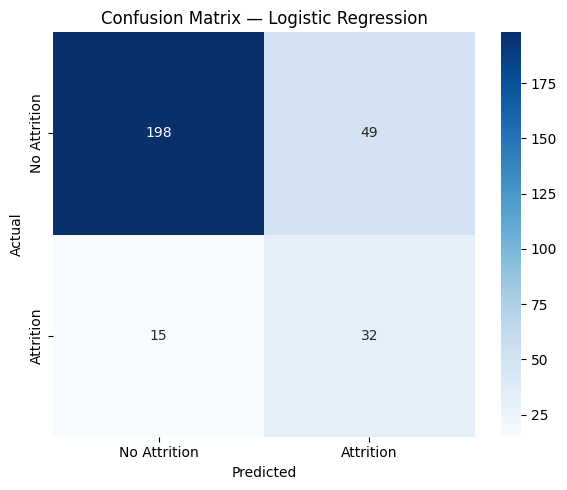

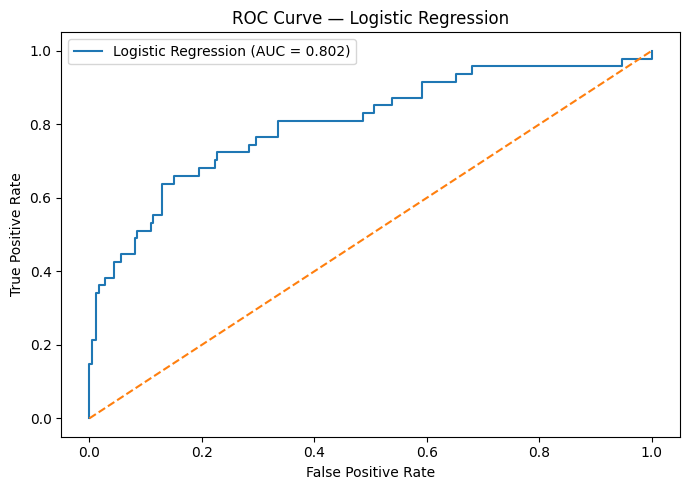

In [ ]:
# Step 19 — Final Model Evaluation

import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

# Final model
final_model = leakage_free_models['Logistic Regression']

# Predictions
y_pred = final_model.predict(X_test_processed)

# Probability of Attrition = Yes
y_prob = final_model.predict_proba(X_test_processed)[:, 1]

# --------------------------------------------------
# 1. Classification Report
# --------------------------------------------------

print("=" * 60)
print("FINAL MODEL — LOGISTIC REGRESSION")
print("=" * 60)

print(
    classification_report(
        y_test_encoded,
        y_pred,
        target_names=['No Attrition', 'Attrition']
    )
)

# --------------------------------------------------
# 2. Confusion Matrix
# --------------------------------------------------

cm = confusion_matrix(
    y_test_encoded,
    y_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Attrition', 'Attrition'],
    yticklabels=['No Attrition', 'Attrition']
)

plt.title('Confusion Matrix — Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 3. ROC Curve
# --------------------------------------------------

fpr, tpr, thresholds = roc_curve(
    y_test_encoded,
    y_prob
)

roc_auc = roc_auc_score(
    y_test_encoded,
    y_prob
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f'Logistic Regression (AUC = {roc_auc:.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Logistic Regression')
plt.legend()
plt.tight_layout()
plt.show()

## Step 20 — Logistic Regression Feature Importance

Logistic Regression provides interpretable coefficients that indicate how each feature influences the probability of employee attrition.

- Positive coefficients increase the likelihood of `Attrition = Yes`.
- Negative coefficients decrease the likelihood of `Attrition = Yes`.
- Larger absolute coefficients indicate stronger influence.

We will identify the most influential features and visualize the strongest positive and negative factors.

TOP 20 FEATURES BY LOGISTIC REGRESSION COEFFICIENT
                              Feature  Coefficient
   cat__JobRole_Laboratory Technician     0.790599
       cat__BusinessTravel_Non-Travel    -0.776303
cat__BusinessTravel_Travel_Frequently     0.737541
                num__LogMonthlyIncome    -0.642030
       cat__JobRole_Research Director    -0.566701
    cat__JobRole_Sales Representative     0.559042
                    num__OvertimeFlag     0.545601
               num__TotalWorkingYears    -0.529098
      cat__JobRole_Research Scientist    -0.508541
              num__NumCompaniesWorked     0.489297
         num__EnvironmentSatisfaction    -0.468697
         num__YearsSinceLastPromotion     0.448417
                             num__Age    -0.436317
                 num__JobSatisfaction    -0.419371
            cat__EducationField_Other    -0.415109
            cat__MaritalStatus_Single     0.414220
                  num__TenureFraction    -0.385535
                  num__YearsAtC

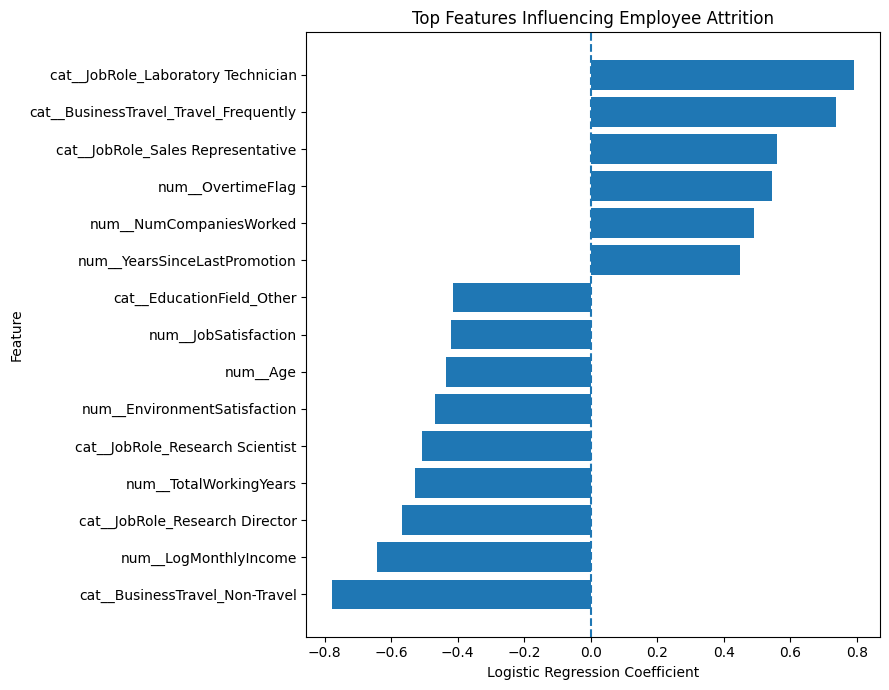

In [29]:
# Step 20 — Feature Importance from Logistic Regression

# Get the fitted Logistic Regression model
logistic_model = final_model.named_steps['model']

# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Create coefficient DataFrame
coefficients = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': logistic_model.coef_[0]
})

# Add absolute coefficient for ranking
coefficients['Absolute_Importance'] = (
    coefficients['Coefficient'].abs()
)

# Sort by absolute importance
coefficients = coefficients.sort_values(
    'Absolute_Importance',
    ascending=False
)

# Display top 20 features
top_features = coefficients.head(20)

print("=" * 60)
print("TOP 20 FEATURES BY LOGISTIC REGRESSION COEFFICIENT")
print("=" * 60)

print(
    top_features[
        ['Feature', 'Coefficient']
    ].to_string(index=False)
)

# Visualization
plot_data = coefficients.head(15).sort_values(
    'Coefficient'
)

plt.figure(figsize=(9, 7))

plt.barh(
    plot_data['Feature'],
    plot_data['Coefficient']
)

plt.axvline(
    x=0,
    linestyle='--'
)

plt.xlabel('Logistic Regression Coefficient')
plt.ylabel('Feature')
plt.title('Top Features Influencing Employee Attrition')

plt.tight_layout()
plt.show()

## Step 21 — Save the Final Model

The final Logistic Regression pipeline contains both the preprocessing steps and the trained model.

Saving the complete pipeline allows us to reuse the model later on new employee data without manually repeating the preprocessing steps.

In [33]:
# Step 21 — Save Preprocessor and Final Model

import joblib

# Save the preprocessing pipeline
joblib.dump(
    preprocessor,
    'employee_attrition_preprocessor.pkl'
)

# Save the trained Logistic Regression model
joblib.dump(
    final_model,
    'employee_attrition_model.pkl'
)

print("Preprocessor saved successfully!")
print("Model saved successfully!")

Preprocessor saved successfully!
Model saved successfully!


## Step 22 — Test the Saved Model on a New Employee

We will load the saved pipeline and use it to predict whether a new employee is likely to leave the company.

The saved pipeline automatically applies the same preprocessing used during training.

In [34]:
# Step 22 — Test the Saved Model

import joblib

# Load preprocessor and model
loaded_preprocessor = joblib.load(
    'employee_attrition_preprocessor.pkl'
)

loaded_model = joblib.load(
    'employee_attrition_model.pkl'
)

# Select one employee from the original test set
new_employee = X_test.iloc[[0]]

# Transform the raw employee data
new_employee_processed = loaded_preprocessor.transform(
    new_employee
)

# Prediction
prediction = loaded_model.predict(
    new_employee_processed
)[0]

# Probability
probability = loaded_model.predict_proba(
    new_employee_processed
)[0, 1]

# Actual result
actual = y_test.iloc[0]

prediction_label = 'Yes' if prediction == 1 else 'No'

print("=" * 60)
print("EMPLOYEE ATTRITION PREDICTION")
print("=" * 60)

print(f"Actual Attrition: {actual}")
print(f"Predicted Attrition: {prediction_label}")
print(f"Attrition Probability: {probability:.2%}")

EMPLOYEE ATTRITION PREDICTION
Actual Attrition: No
Predicted Attrition: No
Attrition Probability: 35.91%
